# 使用 SNN 训练神经形态脉冲编码后的 NinaPro 数据（T=120）

本 Notebook 从 `ninapro_data/spikes/T_120` 读取覆盖同一 200 ms 窗口的 120 步二值脉冲序列。`TAU` 固定为 2.0，以便与 T=40 实验保持相同的网络超参数。

In [1]:
# 设置工作目录，导入依赖包
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()

# 将项目根目录加入导入路径，兼容从项目根目录或 Notebook 目录启动。
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 参数定义

In [2]:
T = 120
DATA_DIR = PROJECT_ROOT / "ninapro_data" / "spikes" / f"T_{T}"

NUM_WORKERS = 8
# 训练参数
BATCH_SIZE = 512
EPOCHS = 100
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4 # 增大weight_decay以减少过拟合
GRADIENT_CLIP = 1.0
SEED = 42
DETERMINISTIC = False
MIXED_PRECISION = True
EVAL_INTERVAL = 1
CHECKPOINT_INTERVAL = 5

# 模型参数；TAU 在不同 T 的实验中保持不变。
INPUT_CHANNELS = 16
HIDDEN_SIZE = 64
NUM_CLASSES = 12
TAU = 2.0
DROPOUT_RATE = 0.1

# 训练结果输出目录
MODEL_NAME = "DropoutPLIFSNN"
EXPERIMENT_NAME = f"{MODEL_NAME}_BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}_HIDDEN{HIDDEN_SIZE}_DROPOUT{DROPOUT_RATE}_TAU{TAU}_WD{WEIGHT_DECAY}"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "spike_ninapro_snn" / f"T_{T}" / EXPERIMENT_NAME

# 单批次诊断不会修改正式模型，可在确认链路正确后关闭。
RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2

# 仅在需要显式恢复训练时设置为 last.pt 路径。
RESUME_FROM = None

print(f"DATA_DIR = {DATA_DIR}")
print(f"MODEL_NAME = {MODEL_NAME}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

DATA_DIR = /root/autodl-tmp/NinaPro/ninapro_data/spikes/T_120
MODEL_NAME = DropoutPLIFSNN
OUTPUT_DIR = /root/autodl-tmp/NinaPro/outputs/spike_ninapro_snn/T_120/DropoutPLIFSNN_BATCH_SIZE512_LR0.01_HIDDEN64_DROPOUT0.1_TAU2.0_WD0.0001


## 2. 随机种子与设备

In [3]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 数据

In [4]:
import torch
from torch.utils.data import DataLoader

from src.data import NinaProWindowDataset

train_dataset = NinaProWindowDataset(DATA_DIR / "train.npz", transform=None)
test_dataset = NinaProWindowDataset(DATA_DIR / "test.npz", transform=None)

for split_name, dataset in (("train", train_dataset), ("test", test_dataset)):
    expected_shape = (INPUT_CHANNELS, T)
    actual_shape = (dataset.num_channels, dataset.window_size)
    if actual_shape != expected_shape:
        raise ValueError(
            f"{split_name} 输入形状应为 {expected_shape}，实际为 {actual_shape}"
        )

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED + 1),
    **loader_options,
)

print(
    f"train samples = {len(train_dataset):,}, "
    f"sample shape = ({train_dataset.num_channels}, {train_dataset.window_size})"
)
print(
    f"test samples  = {len(test_dataset):,}, "
    f"sample shape = ({test_dataset.num_channels}, {test_dataset.window_size})"
)

train samples = 17,839, sample shape = (16, 120)
test samples  = 8,787, sample shape = (16, 120)


## 4. 模型

In [5]:
# from src.models.snn import NinaProSNN

# model = NinaProSNN(
#     input_channels=INPUT_CHANNELS,
#     hidden_size=HIDDEN_SIZE,
#     num_classes=NUM_CLASSES,
#     tau=TAU,
# )
# parameter_count = sum(parameter.numel() for parameter in model.parameters())
# print(model)
# print(f"parameters = {parameter_count:,}")

In [6]:
from src.models import DropoutPLIFSNN

model = DropoutPLIFSNN(
    input_channels=INPUT_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    tau=TAU,
    dropout_rate=DROPOUT_RATE,
)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

DropoutPLIFSNN(
  input_channels=16, hidden_size=64, num_classes=12, tau=2.0, step_mode='m', backend='torch', auto_reset=True, dropout_rate=0.1
  (input_projection): Linear(in_features=16, out_features=64, bias=True)
  (lif1): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (hidden_projection): Linear(in_features=64, out_features=64, bias=True)
  (lif2): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (classifier): Linear(in_features=64, out_features=12, bias=True)
  (dropout1): Dropout(p=0.1)
  (dropout2): Dropout(p=0.1)
)
parameters = 6,030


## 5. 单批次过拟合诊断

诊断使用正式模型的深拷贝，因此不会改变后续正式训练的初始权重。

In [7]:
import copy
import torch

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    # 诊断训练：从每个类别中选择少量样本(2个)来确保模型能够在单批次上过拟合。
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_loader.dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist())
    diagnostic_samples = [train_loader.dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample[0] for sample in diagnostic_samples]),
        torch.stack([sample[1] for sample in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 6. 正式训练

该单元会运行完整训练，并在 `outputs/spike_ninapro_snn` 下保存 history、指标、图像以及 last/best/final 三类检查点。

In [8]:
from src.training import fit

experiment_config = {
    "seed": SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "input_representation": "binary_spikes",
    "input_field": "X",
    "normalization": "none",
    "spike_encoding": {
        "T": T,
        "window_duration_seconds": 0.2,
        "bin_duration_seconds": 0.2 / T,
    },
    "model": {
        "name": MODEL_NAME,
        "input_channels": INPUT_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_classes": NUM_CLASSES,
        "tau": TAU,
        "tau_policy": "fixed_across_T",
        "dropout_rate": DROPOUT_RATE,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    eval_interval=EVAL_INTERVAL,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    normalization_state=None,
    config=experiment_config,
    resume_from=RESUME_FROM,
)

device=cuda, amp=True, backend=spikingjelly-cupy, gpu_resident_data=True, batch_size=512, epochs=1..100


Train 001/100:   0%|          | 0/35 [00:00<?, ?it/s]

Test  001/100:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 001/100 | train loss 2.4907, acc 6.84% | test loss 2.4870, acc 6.53% | lr 2.000e-03 | 0.54s *


Train 002/100:   0%|          | 0/35 [00:00<?, ?it/s]

...

epoch 099/100 | train loss 1.7500, acc 38.29% | test loss 1.7814, acc 37.59% | lr 1.093e-05 | 0.38s


Train 100/100:   0%|          | 0/35 [00:00<?, ?it/s]

Test  100/100:   0%|          | 0/18 [00:00<?, ?it/s]

epoch 100/100 | train loss 1.7495, acc 38.40% | test loss 1.7814, acc 37.61% | lr 2.734e-06 | 0.39s


Best test:   0%|          | 0/18 [00:00<?, ?it/s]

## 7. 最佳模型结果

best epoch       = 85
test accuracy    = 37.71%
macro precision  = 38.31%
macro recall     = 38.42%
macro F1         = 38.01%
注意：以上结果来自 test-selected checkpoint。


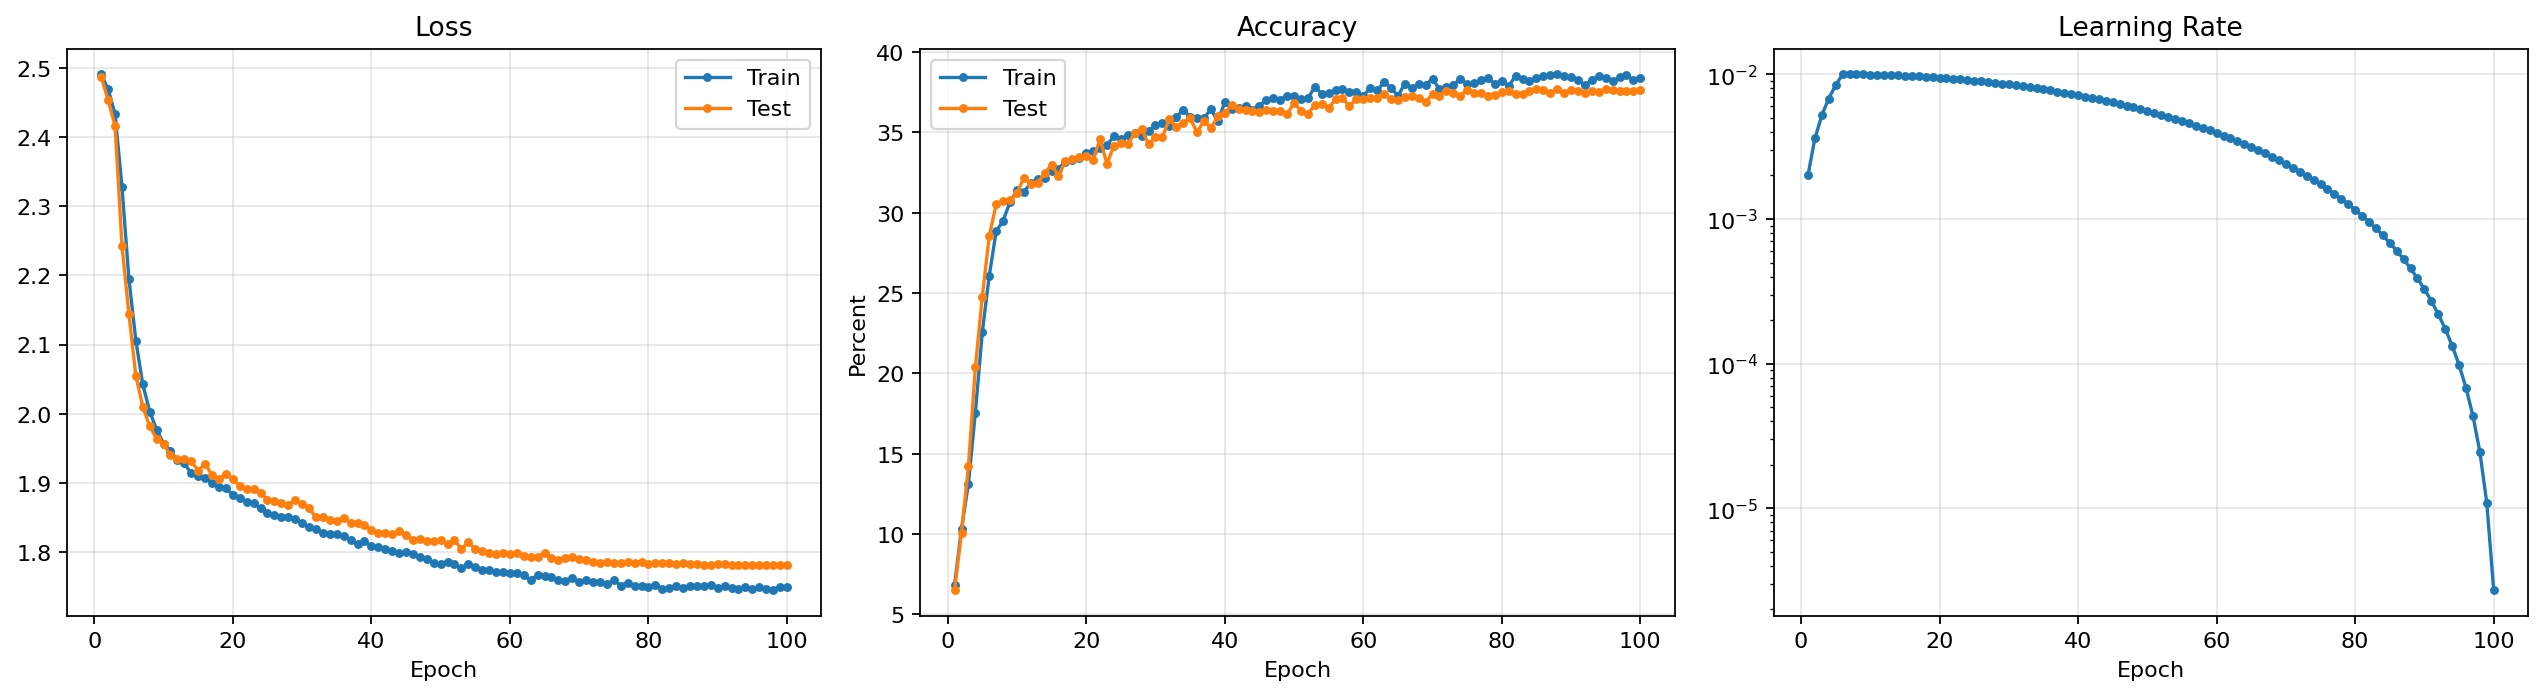

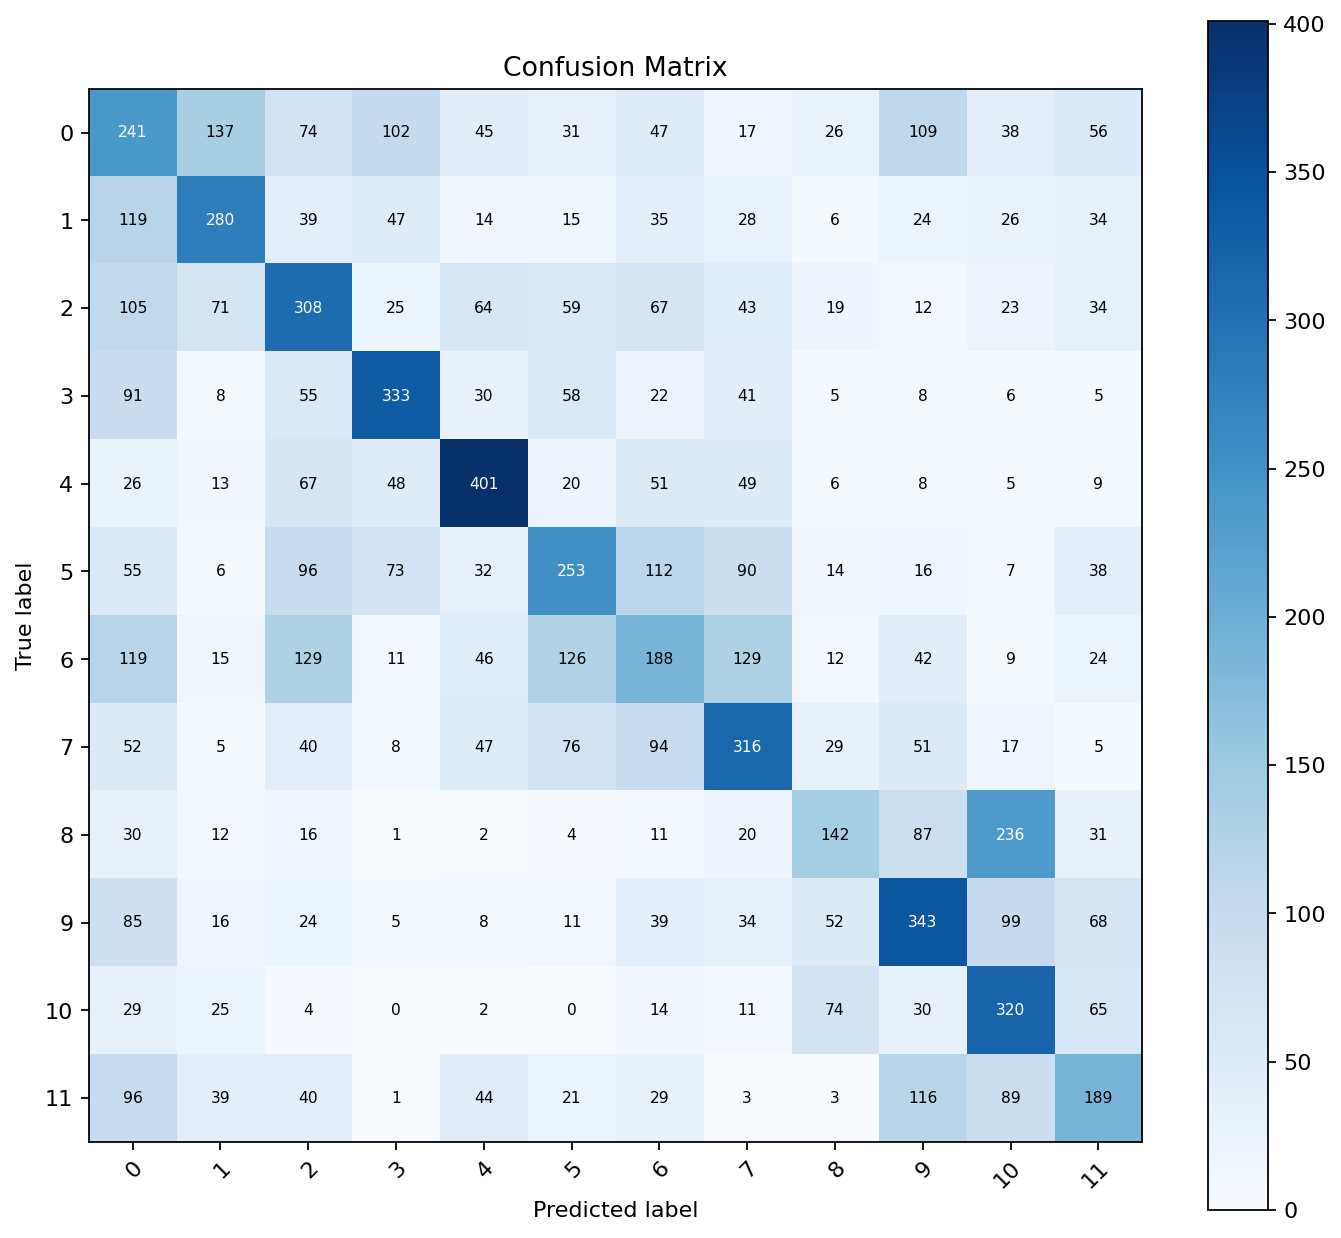

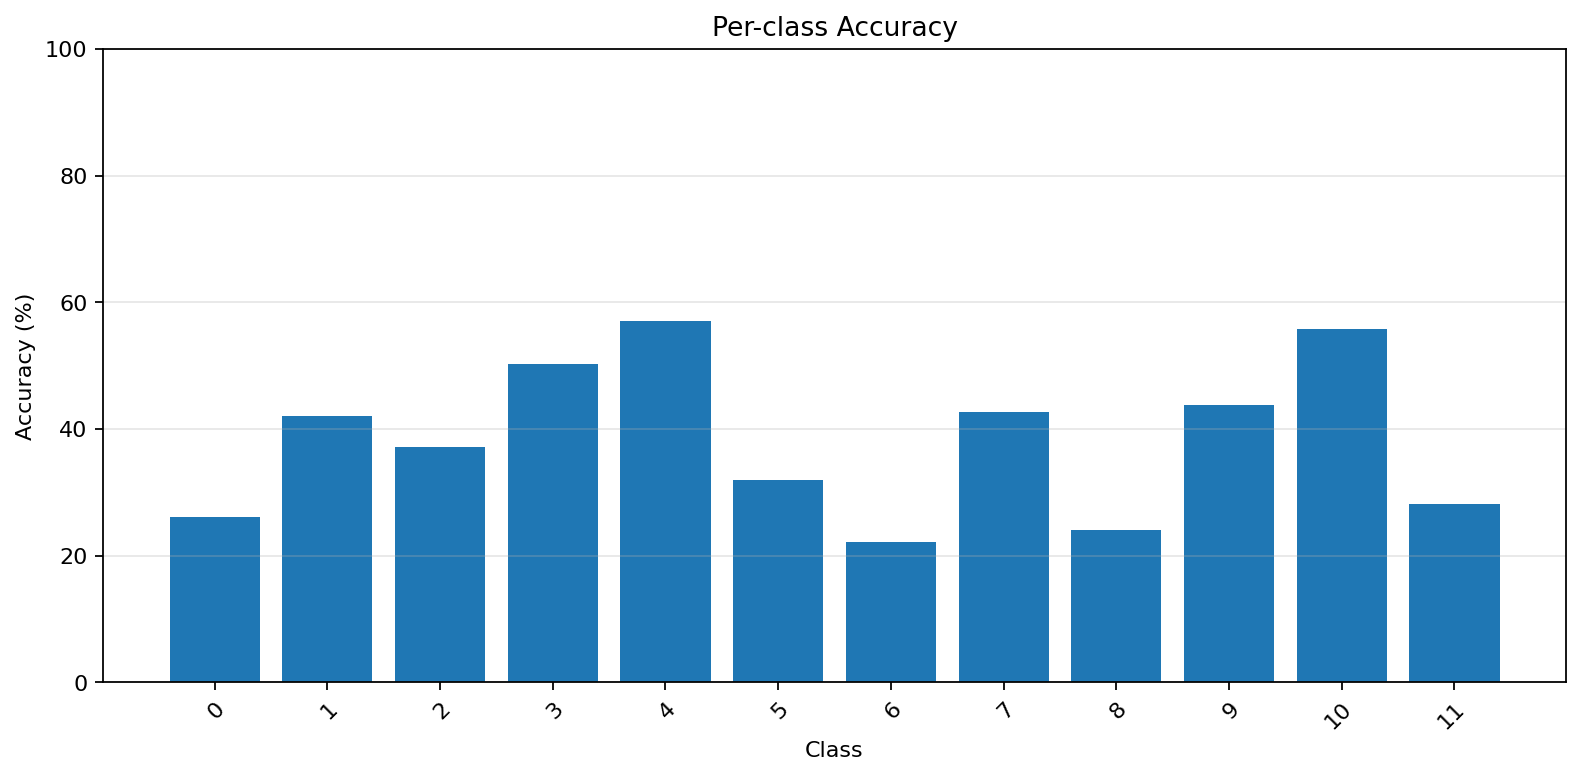

In [9]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
print("注意：以上结果来自 test-selected checkpoint。")

for filename in ("training_curves.png", "confusion_matrix.png", "per_class_accuracy.png"):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))